# Programming Assignment II: Explainability

In this assignment you will train machine learning models and experiment with techniques discussed in the lectures.
This assignment makes use of existing Python libraries for some questions. We have provided links to tutorials/examples if you're not familiar with them yet.

All code that you implement should be in this notebook. You should submit:
* This notebook with your code added. Make sure to add enough documentation. Also provide complete answers to the more theoretical questions in this notebook. These questions are followed by an 'answer indent':
> Answer:

The notebook .ipynb should have the name format `Prog_Explainability_Group_X.ipynb`, where X is your programming group ID.

Important notes:
* Deadline for this assignment is **Friday, June 5, 17:00**.
* Send the notebook to Stan Meyberg (s.j.meyberg@uu.nl), Hugh Mee Wong (h.m.wong@uu.nl) and Heysem Kaya (h.kaya@uu.nl), CCing your programming partner.
* Title of the email: [INFOMHCML] Explainability programming assignment submission [X], with X the number of your group.
* The TAs will be available **online** to assist you with the assignment on **Thursday, May 21 after the lecture between 15:15-16:15. YALE09 - MGB 1.112 will be also available for self-study.**.
* There will be another lab session to assist you with the assignment on **Tuesday, June 2, between 11:00-12:45 at YALE09 - MGB 1.120 and MGB 1.112**.

### Installation

For this assignment, we are going to use the following Python packages:
graphviz, matplotlib, pandas, statsmodels, openpyxl, interpret, and scikit-learn.

In [1]:
# Installing packages on Google Colab (will take about a minute) - uncomment the lines below and run this cell if you work on google Colab
!pip install graphviz > /dev/null
!pip install matplotlib pandas statsmodels openpyxl > /dev/null
!pip install -U interpret > /dev/null
!pip install -U scikit-learn > /dev/null

In [ ]:
# Installing packages on your local machine - uncomment the lines below and run if you run on your local machine
%pip install graphviz
%pip install matplotlib pandas statsmodels openpyxl
%pip install -U interpret
%pip install -U scikit-learn

     ---------------------------------------- 47.3/47.3 kB 2.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 9.6/9.6 MB 2.4 MB/s eta 0:00:00
     -------------------------------------- 233.3/233.3 kB 2.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 15.6/15.6 MB 2.5 MB/s eta 0:00:00
     ---------------------------------------- 9.9/9.9 MB 3.4 MB/s eta 0:00:00
     -------------------------------------- 780.1/780.1 kB 3.8 MB/s eta 0:00:00
     -------------------------------------- 554.9/554.9 kB 3.2 MB/s eta 0:00:00
     -------------------------------------- 139.8/139.8 kB 4.2 MB/s eta 0:00:00
     -------------------------------------- 359.7/359.7 kB 4.5 MB/s eta 0:00:00
     ---------------------------------------- 7.2/7.2 MB 3.8 MB/s eta 0:00:00
     ---------------------------------------- 4.0/4.0 MB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
     -------------------------------------- 103.4/103.4 kB 5.8 MB/s eta 0:00:00
     ---------------------------------------- 1.7/1.7 MB 4.3 MB/s eta 0:00:00
     -------------------------------------- 226.5/226.5 kB 4.6 MB/s eta 0:00:00
     ---------------------

  DEPRECATION: dash-cytoscape is being installed using the legacy 'setup.py install' method, because it does not have a 'pyproject.toml' and the 'wheel' package is not installed. pip 23.1 will enforce this behaviour change. A possible replacement is to enable the '--use-pep517' option. Discussion can be found at https://github.com/pypa/pip/issues/8559

[notice] A new release of pip available: 22.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl (8.1 MB)
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.7.2
    Uninstalling scikit-learn-1.7.2:
      Successfully uninstalled scikit-learn-1.7.2
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Read the data
We are going to use the ChaLearn LAP-FI (First Impressions) Dataset. This dataset contains 10.000 data points, which correspond to videos collected from YouTube and annotated via Amazon Mechanical Turk for the BIG-5 personality impressions: openness, extraversion, conscientiousness, neuroticism, agreeableness.

These five personality impression scores will be used as features to predict the outcome variable: a job interview invitation.

For a detailed description, see the [paper of the dataset](https://ieeexplore.ieee.org/abstract/document/7966041?casa_token=1Y03H5ykCqsAAAAA:VLhCcjAgByJ2hTdKhulmIUiXIVepEJfFyB7HM0XVts7bN8Gi8wMsiTT0qZ--I_kq8wiUHIpPN7es).

## Accessing the data
We will use the dataset file called `xai_dataset.csv`, which can be downloaded from Brightspace.

Depending on your setup, you can use one of the following three options to load the dataset.

### Option 1 - Upload the file manually in Google Colab
This is the easiest option if you are only using the notebook temporarily.

1. Open the Files tab in Google Colab.
2. Click the Upload button and upload `xai_dataset.csv`.
3. After uploading, copy the file path.
4. Run the code cell below using your file path.

> Note: You will need to upload the file again every time you start a new Colab session.


### Option 2 - Mount your Google Drive in Google Colab
This option is useful if you want the dataset to remain available across multiple sessions.

1. Upload `xai_dataset.csv` to your Google Drive.
2. Run the provided code cell to mount your Google Drive. This will ask you for permission to access your Google Drive files and then you can access the data.
3. Follow the instructions in the code cell below.

> You will be asked to grant Colab permission to access your Google Drive.


### Option 3 - Run the notebook locally
If you are running the notebook on your own machine:

1. Place the `xai_dataset.csv` file in the same folder as this notebook.
2. Run the local loading code cell below.

> In this case, no upload or Google Drive connection is required.

In [ ]:
# Run this cell only if you use Google Colab and choose option 2 for loading the data
from google.colab import drive
drive.mount('/content/gdrive')

# Make sure you uploaded all_df.csv to your Google Drive and change the path
# to the directory it is located in (usually in content/gdrive/MyDrive/...)
%cd  '/content/gdrive/MyDrive/Colab Notebooks/HCML/Explainability'

In [30]:
# Run this cell (both when working locally or with Google Colab)
import pandas as pd

data = pd.read_csv("xai_dataset.csv")
print("Data loaded")
data.head()

Data loaded


,Unnamed: 0,extraversion,neuroticism,agreeableness,conscientiousness,interview,openness,id,split,YouTubeID,...,Gender,age_group,gender_eth,gender_age,extraversion_binary,neuroticism_binary,agreeableness_binary,conscientiousness_binary,openness_binary,interview_binary
0,0,0.523364,0.552083,0.626374,0.601942,0.504673,0.488889,J4GQm9j0JZ0.003.mp4,training,J4GQm9j0JZ0,...,2,2,2_2,2_2,1,1,1,1,0,1
1,1,0.345794,0.375000,0.472527,0.582524,0.457944,0.366667,zEyRyTnIw5I.005.mp4,training,zEyRyTnIw5I,...,2,2,2_1,2_2,0,0,0,1,0,0
2,2,0.252336,0.291667,0.406593,0.485437,0.373832,0.511111,nskJh7v6v1U.004.mp4,training,nskJh7v6v1U,...,2,1,2_1,2_1,0,0,0,0,0,0
3,3,0.457944,0.489583,0.505495,0.398058,0.457944,0.377778,6wHQsN5g2RM.000.mp4,training,6wHQsN5g2RM,...,1,2,1_1,1_2,0,0,0,0,0,0
4,4,0.607477,0.489583,0.406593,0.621359,0.570093,0.622222,dQOeQYWIgm8.000.mp4,training,dQOeQYWIgm8,...,2,1,2_1,2_1,1,0,0,1,1,1


### Loading and preprocessing the data
There are 6000, 2000 and 2000 examples for training, validation/development and test set respectively. In the data this is indicated by the feature `split`.

The training set is used to train models, the validation/development set to optimize the models hyper-parameters, and the test set to evaluate the trained model.

In [31]:
import numpy as np

# global variables
FEATURE_NAMES = ['openness','extraversion', 'agreeableness', 'neuroticism','conscientiousness']
LABEL_NAME = 'interview'

def load_data():
    def split_feature_label(data_set):
        features = data_set[FEATURE_NAMES]
        labels = data_set[LABEL_NAME]
        return features, labels

    train_set = data[data['split'] == 'training']
    val_set = data[data['split'] == 'validation']
    test_set = data[data['split'] == 'test']

    train_features, train_labels = split_feature_label(train_set)
    val_features, val_labels = split_feature_label(val_set)
    test_features, test_labels = split_feature_label(test_set)

    return train_features, train_labels, val_features, \
        val_labels, test_features, test_labels

# Load the data with the function above
(train_features, train_labels, dev_features, \
        dev_labels, test_features, test_labels) = load_data()

# Part 1. Intrinsically interpretable models

### **1. Linear Regression**

Train a linear regression model (we recommend the `statsmodels.api` package with the ordinary least squares model `sm`).

Hint: to get a linear regression model, you should manually add a constant variable (usually called bias or intercept - that has a fixed value of 1 for all instances) to the data, either by adding it column yourself or by using the `add_constant()` function.



**Q1.1**

Provide the $R^2$ (goodness of fit) statistic and for each feature (+ the bias variable), the following in tabular format:
* Weight estimate (coef)
* SE (standard error of estimates)
* T-statistic

Hint: You can print the summary of the model using `.summary()` to do this. This gives an extensive overview of the performance of a model.

,interview
0,0.504673
1,0.457944
2,0.373832
3,0.457944
4,0.570093
...,...
9995,0.177570
9996,0.728972
9997,0.411215
9998,0.560748


In [ ]:
# We recommend the statsmodels package
import statsmodels.api as sm

# Your code to add a bias/intercept variable
X = data[["openness",
        "extraversion",
        "agreeableness",
        "neuroticism",
        "conscientiousness"]]

y = data["interview"]

# Add intercept column
X = sm.add_constant(X)

X

# Train the model and print out the summary


,const,openness,extraversion,agreeableness,neuroticism,conscientiousness
0,1.0,0.488889,0.523364,0.626374,0.552083,0.601942
1,1.0,0.366667,0.345794,0.472527,0.375000,0.582524
2,1.0,0.511111,0.252336,0.406593,0.291667,0.485437
3,1.0,0.377778,0.457944,0.505495,0.489583,0.398058
4,1.0,0.622222,0.607477,0.406593,0.489583,0.621359
...,...,...,...,...,...,...
9995,1.0,0.300000,0.289720,0.208791,0.312500,0.135922
9996,1.0,0.722222,0.719626,0.670330,0.781250,0.572816
9997,1.0,0.677778,0.355140,0.472527,0.395833,0.446602
9998,1.0,0.622222,0.467290,0.527473,0.645833,0.669903


**Q1.2**

Which three features are the most important?

> Answer:

**Q1.3**

How does the predicted 'interview' score change with an 0.1 increase of the 'conscientiousness' feature given that all other feature values remain the same?

> Answer:

**Q1.4**

Show bar graph illustrations of the feature effects for the first two validation set instances.

> Answer:

In [ ]:
# Compute the Feature Effects

# Show bar graphs

**Q1.5**

Reflection: why would training a regression tree not work well for this dataset in terms of model interpretability? And under what conditions could the dataset be used with a decision tree to yield an interpretable model?

> Answer:

### **2. Explainable Boosting Model**
Train an Explainable Boosting Machine (EBM) with [InterpretML](https://interpret.ml/docs/ebm.html). EBM is a Generalized Additive Model (GAM) that is highly intelligible and explainable.


In [ ]:
from interpret.glassbox import ExplainableBoostingRegressor

# train the ebm using the training set




The `interpret` package provides both global and local explanation functions: `explain_global()` and `explain_local()` can be used to interpret a ML model.

**Q2.1**

Report EBM's Root Mean Square Error (RMSE) performance on the development and test sets (both rounded to three decimal digits) and then visualize/provide global (model-wise) feature importances for EBM as a table or figure.

Hint: You can use the `show` function from the package for this

In [ ]:
from interpret import show
from sklearn.metrics import root_mean_squared_error

# RMSE calculation

# EBM Global feature importances


**Q2.2**

What are the most important two features in EBM? Are they the same as in the linear model?

> Answer:

Now, to have an idea how EBM treats the input and generates the explanation, visualize EBM local explanations on a synthetic instance generated from training set mean feature vector as input and training set mean response as output.



In [ ]:
# EBM Local explanation for training set mean vector with corresponding training set mean label
train_mean_x = pd.DataFrame(train_features.mean(axis=0)).T
train_mean_y = pd.DataFrame([train_labels.mean()])

print(train_mean_x)
print(train_mean_y)

**Q2.3**

Now, visualize local (instance-wise) feature importances for the first two instances of the development set.

In [ ]:
# EBM local explanations for the first two development set instances

**Q2.4**

Let's compare these feature importances with the feature effects in question 1.4.

* Are the feature contribution orderings the same in both models for the two instances?
> Answer:

* For the second example's explanation, why do you think the contribution of *conscientiousness* is positive, while the contribution of *agreeableness* is negative? (Hint: consider the feature values relative to the training set mean values you calculated / processed in the former subquestion.)
> Answer:

# Part 2. Model-Agnostic Methods for Interpreting/Explaining NN

### **3. Training Neural Networks**
Train a one-layer Neural Network (multi-layer perceptron (MLP) Regressor, but with one layer) with the following settings:

- Activation function: ReLU
- Size of the hidden layer: 50 neurons
- Recommended optimizer/solver: Adam

For a tutorial see [Tutorial](https://scikit-learn.org/stable/modules/neural_networks_supervised.html).

**Q3.1**

Apply the trained neural network model to the development set to find the best hyperparameters (such as learning rate). Report the Root Mean Square Error (RMSE) performance for both development and test sets (rounded to three decimal digits).

**Note.** A development set RMSE below 0.045 is reasonable, then you can apply the corresponding model on the test set.

In [32]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

def calculate_rmse(y_true, y_pred):
  return np.sqrt(mean_squared_error(y_true, y_pred))

model = MLPRegressor(
    activation='relu',
    hidden_layer_sizes=(50,),
    solver='adam',
    random_state=42,
    verbose=True,
  )

# model = MLPRegressor(
#     hidden_layer_sizes=(50,),
#     activation="relu",
#     solver="adam",
#     learning_rate_init=0.001,
#     alpha=0.0001,
#     batch_size=64,
#     max_iter=1000,
#     early_stopping=True,
#     n_iter_no_change=20,
#     random_state=42,
#     verbose=True
# )

# Train the MLPRegressor and show RMSE on development set
model.fit(X=train_features, y=train_labels)

# RMSE on development set
dev_predictions = model.predict(dev_features)
dev_rmse = calculate_rmse(y_true=dev_labels, y_pred = dev_predictions)
print("\n\n")
print(f"Development RMSE: {dev_rmse:.3f}")


# RMSE on test set
test_predictions = model.predict(test_features)
test_rmse = calculate_rmse(y_true=test_labels, y_pred = test_predictions)
print("\n\n")
print(f"Test RMSE: {test_rmse:.3f}")

Iteration 1, loss = 0.23018199
Iteration 2, loss = 0.02306432
Iteration 3, loss = 0.00553179
Iteration 4, loss = 0.00416199
Iteration 5, loss = 0.00314068
Iteration 6, loss = 0.00222583
Iteration 7, loss = 0.00179779
Iteration 8, loss = 0.00155091
Iteration 9, loss = 0.00139846
Iteration 10, loss = 0.00129216
Iteration 11, loss = 0.00122536
Iteration 12, loss = 0.00116088
Iteration 13, loss = 0.00112236
Iteration 14, loss = 0.00109409
Iteration 15, loss = 0.00107577
Iteration 16, loss = 0.00105664
Iteration 17, loss = 0.00104418
Iteration 18, loss = 0.00103554
Iteration 19, loss = 0.00102806
Iteration 20, loss = 0.00102088
Iteration 21, loss = 0.00101250
Training loss did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.



Development RMSE: 0.044



Test RMSE: 0.045


**Q3.2**
Considering the test set performances and models' characteristics, would you use EBM or NN in a real-life application?

NB: Such a model should not and cannot (according to the EU AI Law) be used for selecting people for a job interview. However, it can be used in an application for personal skill development / training purposes.

> Answer:

Now we can analyze factors that influence the predictions. Both Partial Dependence Plots (PDP) and Individual Conditional Expectation (ICE) plots can be used to visualize and analyze interaction between the target response and a set of input features of interest.

See the [Documentation](https://scikit-learn.org/stable/modules/partial_dependence.html) on how to use PDPs and ICEs.

**Q3.3**

Generate univariate and bivariate PDPs for the `conscientiousness` and `agreeableness` features with the neural network you trained above.

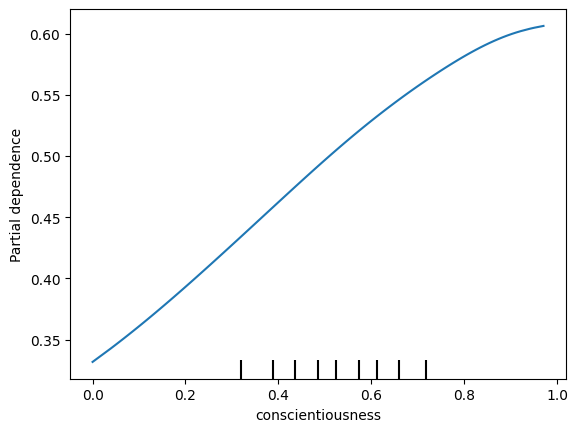

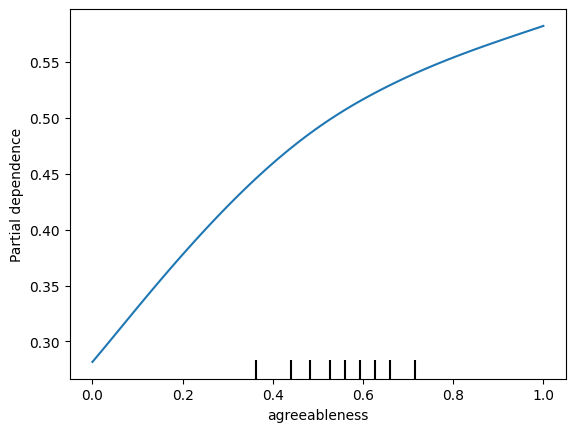

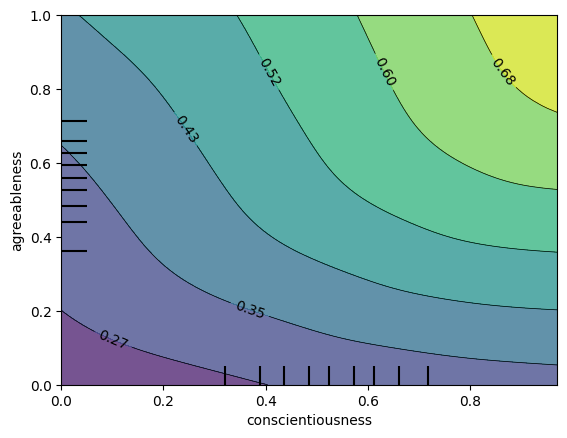

In [33]:
from sklearn.inspection import PartialDependenceDisplay

# PDPs
# A. Univariate
PartialDependenceDisplay.from_estimator(
    estimator=model, X=train_features, features = ['conscientiousness']
)

PartialDependenceDisplay.from_estimator(
    estimator=model, X=train_features, features = ['agreeableness']
)


# B. Bivariate
PartialDependenceDisplay.from_estimator(
    estimator=model, X=train_features, features = [('conscientiousness','agreeableness')]
)

**Q3.4**

What do these plots show?

> Answer:
> **A - Univariate plots**
> *   Both features monotonically increase the prediction value, as their value increases
> *   As conscientiousness increases from 0 to 1, the predicted target value increases roughly from 0.33 to 0.61.
> *   As agreeableness increases from 0 to 1, the predicted target value increases roughly from 0.27 to 0.58.
> * Total increase due to conscientiousness: **dy = 0.61-0.33 = 0.28**. Total increase due to agreeableness: **dy = 0.58-0.27 - 0.31**. Overall very similar effect of both features
> * None of the feaures appears to have a purely linear relationship with the prediction, unlike the lecture slides example (lec. 7, p. 11), therefore we do not interpret them by calculating their slope.



> **B - Bivariate plot**
> * Both features have a positive effect on the rpediciton, meaning that the further we move to the right (increasing conscientiousness) and the further we move up (increasing agreeableness) the rpediction also increases
> * The highest prediction values are when the features are simultaneously high. Top right corner is  where the prediction value is at its highest (so high agreeableness and high conscietiousness).
> * The lines are not completely straight, indicating feature interaction. In other words, the effect of an increase in conscientiousness depends on the level of agreeableness as well.  Given that the lines are more horizontal towards the lower end of agreeableness values and more vertical towards the higher end, the same increase in conscientiousness (e.g. from 0.3 to 0.6) would have a larger effect on the prediction around higher values of agreeableness (e.g. ~0.12 increase for agreeableness level of 0.8) than it would for lower levels of agreeableness (<0.08 for agreeableness at 0.1). A similar conclusion can be drawn for agreeableness, as the effect of increase in agreeableness is more prominent for higher conscientiousness values


**Q3.5**

Now generate ICE plots for each feature.

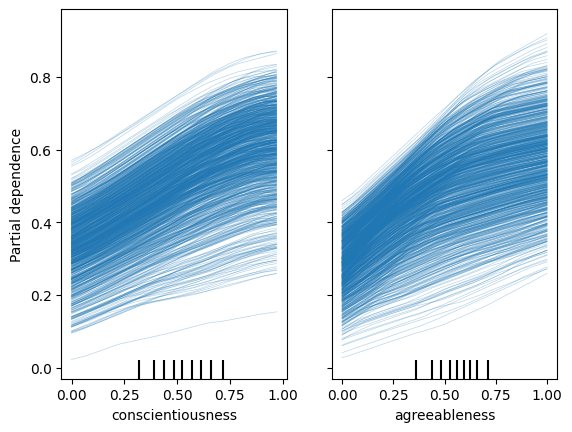

In [34]:
# ICEs

PartialDependenceDisplay.from_estimator(
    model,
    train_features,
    features=["conscientiousness", "agreeableness"],
    kind="individual"
)

**Q3.6**

What can you conclude from ICE plots above?

> Answer:
> Each figure consists of #len(train_features) (6000) plots, of the effect of increase in conscientiousness and agreeableness on the prediciton value, for each training set instance separately. As we see, the ice curves are mostly parallel for both features (with the exception of the lower end ones in the agreeableness plot). This suggests that the effects of conscientiousness and agreeableness are consistent across most individual instances. The difference in height aross each curve is due to the different baseline prediction levels of each individual instance. So had we used the centering trick, the curves would overlap more, as their shape is very similar.

**Q3.7**

Implement the Partical Dependence Function (PDF) for univariate analysis of the trained neural network model.


In [60]:
def PDF(X: pd.DataFrame, model: MLPRegressor, feature: str) -> tuple[np.ndarray, np.ndarray]:
  """
  Args:
      X (pd.DataFrame): The dataset.
      model (MLPRegressor): The trained model on which to run the PDF.
      feature (str): The features for which the partial dependence function should be plotted.

    Returns:
      x_values (np.ndarray): The independent variable values.
      f_values (np.ndarray): The corresponding output per x value.
  """
  # # Note: uncomment the lines below and complete the right hand side (where you see '..' to set them to suitable values, respective explanations are provided for each variable
  num_samples = 101  # set the number of samples/steps to slice the range of the continuous feature, e.g., 101.
  min_val = X[feature].min()   # minimum value of the given feature
  max_val = X[feature].max()      # maximum value of the given feature
  step_size = (max_val - min_val) / (num_samples - 1)   # see the algorithm in corresponding lecture slides to calculate the step size as a function of the above variables
  x_values = np.linspace(min_val, max_val, num_samples)    # x_values at which we will calculate the partial function of the given feature
  f_values = np.zeros(num_samples)     # needs initialization: the calculated partial function values corresponding to x_values will be stored here and returned via this variable

  for k in range(num_samples):
    X_fixed_value = X.copy()
    X_fixed_value[feature] = x_values[k]

    # Let the model predict and calculate the mean f_value for this k
    predictions = model.predict(X_fixed_value)
    f_values[k] = np.mean(predictions)

  return x_values, f_values

**Q3.8**

Calculate and visualize the feature importances obtained from your PDF algorithm using a bar graph.

Hints and questions to derive at your answer:
- How do we calculate the feature importance given the x_values and f_values of the PDF algorithm?
- Which output of the fitted linear model could indicate how strongly the predictions change when the feature changes?

In [66]:
# First calculate the x_values and f_values for each feature

feature_pdf = {}

for feature in FEATURE_NAMES:
  x_values, f_values = PDF(train_features, model, feature)
  feature_pdf[feature] = (x_values, f_values)

# feature_pdf

{'openness': (array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
         0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
         0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
         0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
         0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
         0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
         0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76,
         0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87,
         0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98,
         0.99, 1.  ]),
  array([0.4555622 , 0.4563681 , 0.45719176, 0.45803324, 0.45889065,
         0.45976117, 0.46064772, 0.46154792, 0.4624599 , 0.46338283,
         0.46431648, 0.46526005, 0.46621262, 0.46717117, 0.46813347,
         0.46909993, 0.47007206, 0.47105025, 0.47203251, 0.47301684,
         0.474

In [71]:
from scipy.stats import linregress

feature_importance_values = {}

for feature in FEATURE_NAMES:
  x_values, f_values = feature_pdf[feature]
  slope, intercept = linregress(x_values, f_values)[:2]
  feature_importance_values[feature] = slope

feature_importance_values


{'openness': np.float64(0.06239685441241223),
 'extraversion': np.float64(0.22446699322699326),
 'agreeableness': np.float64(0.29671372253480416),
 'neuroticism': np.float64(0.2735715975645065),
 'conscientiousness': np.float64(0.304351314476617)}

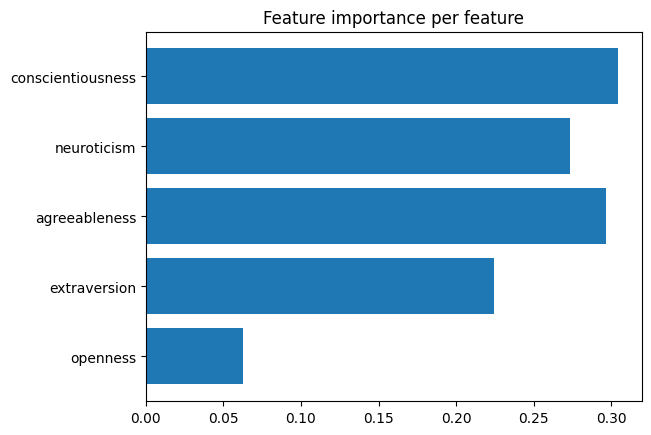

In [75]:
import matplotlib.pyplot as plt

# now plot the feature importances in a bar graph (Hint: use plt.barh())
FEATURE_NAMES = ['openness','extraversion', 'agreeableness', 'neuroticism','conscientiousness']

plt.barh(FEATURE_NAMES, list(feature_importance_values.values()))
plt.title("Feature importance per feature")
plt.show()



**Q3.9**

What are the two most important features obtained by the PDF algorithm for the MLP model? How do these two features compare to the top two features from the Linear Model and the EBM?

> Answer:
> the top 2 features according to the bar graph are conscentiousness and agreeableness


### **4. Permutation Feature Importance**

**Q4.1**

Implement the permutation feature importance algorithm using RMSE as the error function. No existing libraries (barring the RMSE from `sklearn` and a function for random sampling / permutation) are allowed to be used, you will implement it yourself with the framework below.

In [78]:
from collections.abc import Callable
from sklearn.metrics import root_mean_squared_error


def PFI(X: pd.DataFrame, labels: pd.Series, model: MLPRegressor, error_func: Callable) -> pd.DataFrame:
  """
  Args:
      X (pd.DataFrame): The dataset.
      labels (pd.Series): The corresponding ground truth labels to the dataset.
      model (MLPRegressor): The trained model on which to run PFI.
      error_func (Callable): The error function.

  Returns:
      results_df (pd.DataFrame): The results of PFI (the feature importances) in a dataframe.
  """
  results = []

  # Calculate the base error using the error function sent as parameter (error_func)
  base_error = error_func(labels, model.predict(X))

  for feature in X:
    X_copy = X.copy()

    # Scramble the values of the given feature/predictor randomly
    X_copy[feature] = np.random.permutation(X_copy[feature])

    # Calculate the new error
    new_error = error_func(labels, model.predict(X_copy))

    # Append the increase in error (=predictor score) to the list of results
    error_increase = new_error - base_error
    results.append(error_increase)

  # Put the results into a pandas dataframe called results_df and rank the predictors by score
  results_df =  pd.DataFrame({
      'feature': X.columns,
      'score': results
  }).sort_values(by='score', ascending=False)

  return results_df


# run the PFI algorithm
results_df = PFI(dev_features, dev_labels, model, root_mean_squared_error)

**Q4.2**

Visualize the feature importances obtained by your PFI algorithm with a bar graph.

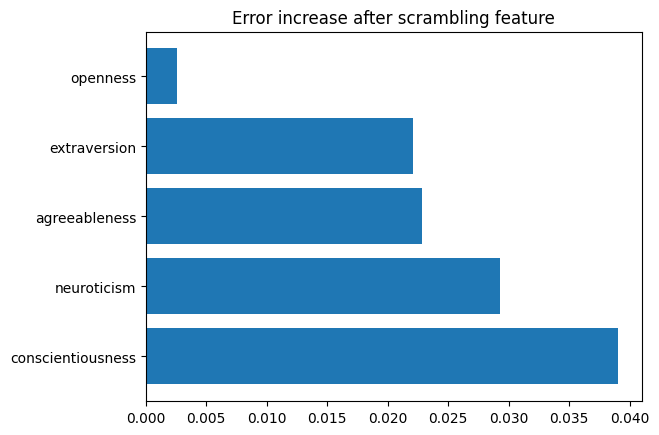

In [80]:
# Bar graph of feature importances

plt.barh(results_df['feature'], results_df['score'])
plt.title("Error increase after scrambling feature")
plt.show()

**Q4.3**

What are the two most important features obtained by the permutation feature importance algorithm for the MLP model? How do these two features compare to the top two features found by PDF and those from EBM?

> Answer:
> The top 2 features, in terms of how much the predicton error increases when they are scrambled are conscientiousness and neuroticism, in that order. The former is also amongst the top 2 most important found by the PDF (and specifically the highest ranked one as well). As far as EBM goes...